<a href="https://colab.research.google.com/github/Rogerio-mack/IMT_CD_2026/blob/main/Modelo_ARIMA_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo ARIMA

<img src="https://github.com/Introducao-Series-Temporais-em-Python/Book/raw/main/Figures/Fluxograma2.png" width=300 align="middle">

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

# **CASE: Sales Commodities**

Abaixo dados de 3 anos de vendas mensais, a partir de 2021, em milhares de reais, de uma Commodity. Empregue um modelo ARIMA para fazer a predição dos próximos 3 meses.

In [2]:
#@markdown Just run

serie = '''
"Month","Sales"
"1-01",266.0
"1-02",145.9
"1-03",183.1
"1-04",119.3
"1-05",180.3
"1-06",168.5
"1-07",231.8
"1-08",224.5
"1-09",192.8
"1-10",122.9
"1-11",336.5
"1-12",185.9
"2-01",194.3
"2-02",149.5
"2-03",210.1
"2-04",273.3
"2-05",191.4
"2-06",287.0
"2-07",226.0
"2-08",303.6
"2-09",289.9
"2-10",421.6
"2-11",264.5
"2-12",342.3
"3-01",339.7
"3-02",440.4
"3-03",315.9
"3-04",439.3
"3-05",401.3
"3-06",437.4
"3-07",575.5
"3-08",407.6
"3-09",682.0
"3-10",475.3
"3-11",581.3
"3-12",646.9
'''

In [3]:
import io
df = pd.read_csv(io.StringIO(serie))
df.head()

,Month,Sales
0,1-01,266.0
1,1-02,145.9
2,1-03,183.1
3,1-04,119.3
4,1-05,180.3


# **1. Preparação e Exploração dos Dados**

**Notas**

* Dataframes índice datetime
* Operações de resample (diário → mensal)
* Preechimento de lacunas
* Decomposição da Série


In [4]:
df['Month'] = '202' + df['Month']
df['Month'] = pd.to_datetime(df['Month'], format='%Y-%m')
df.index = pd.DatetimeIndex(df['Month'],freq='MS')
df.drop(columns=['Month'], inplace=True)

display(df.head())
display(df.tail())
display(df.shape)

,Sales
Month,
2021-01-01,266.0
2021-02-01,145.9
2021-03-01,183.1
2021-04-01,119.3
2021-05-01,180.3


,Sales
Month,
2023-08-01,407.6
2023-09-01,682.0
2023-10-01,475.3
2023-11-01,581.3
2023-12-01,646.9


(36, 1)

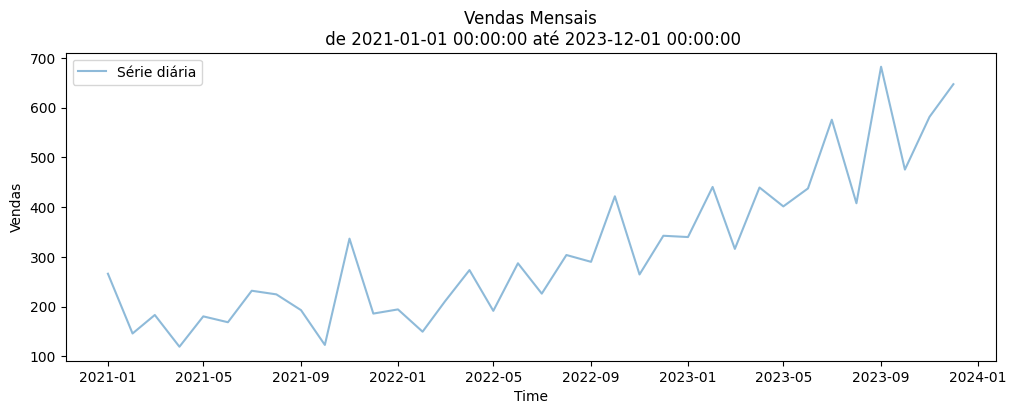

In [5]:
plt.figure(figsize=(12, 4))

plt.plot(df.index,df.Sales,label='Série diária',alpha=0.5)
plt.title ('Vendas Mensais\n de ' + str(df.index.min()) + ' até ' + str(df.index.max()))
plt.xlabel('Time')
plt.ylabel ('Vendas')
plt.legend()

plt.show()

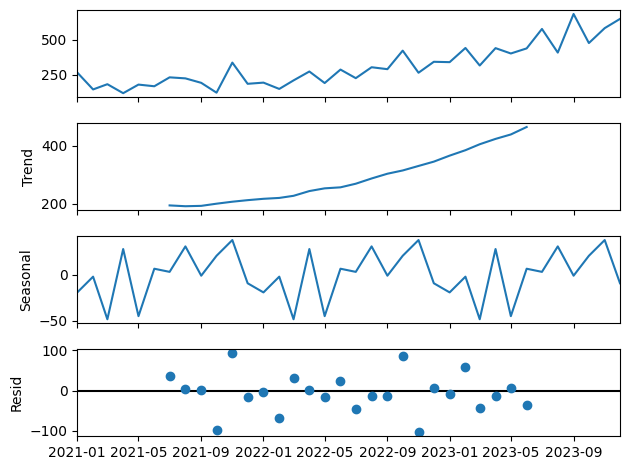

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomp = seasonal_decompose(df, model='additive')

fig = decomp.plot()

# **2. Pressupostos**

- Estacionariedade
- Homocedasticidade
- Para modelo ARIMA, ausência de periodicidade
- Outros

# **3. Estacionariedade**

Teste **Augmented Dickey-Fuller (ADF)**. Apenas alternativamente, Kwiatkowski–Phillips–Schmidt–Shin (KPSS).

- $H_0$: A série temporal não é estacionária.
- $H_{a}$: A série temporal é estacionária (em termos de tendência)

**Notas**

* Série não estacionária (pressuposto para aplicação do modelo ARIMA):
> * Diferenciação (= Série de Diferença)
> * Log
> * Ou outra transformação

* O ARIMA(p,d,q), aceita unicamente a diferenciação. Para outras transformações você precisar fazer manual.

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

p = adfuller(df.Sales)[1]
print(f'p-valor: {p:.3f}')

if p < 0.05:
    print('Há evidência significativa de que a série seja estacionária  (p < 0.05).')
else:
    print('Não há evidência significativa de que a série seja estacionária (p >= 0.05).')


p-valor: 1.000
Não há evidência significativa de que a série seja estacionária (p >= 0.05).


# **4. Diferenciação, $d$**

In [ ]:
p = adfuller(df.Sales.diff(1).dropna())[1]
print(f'p-valor: {p:.3f}')

if p < 0.05:
    print('Há evidência significativa de que a série seja estacionária  (p < 0.05).')
else:
    print('Não há evidência significativa de que a série seja estacionária (p >= 0.05).')

p-valor: 0.000
Há evidência significativa de que a série seja estacionária  (p < 0.05).


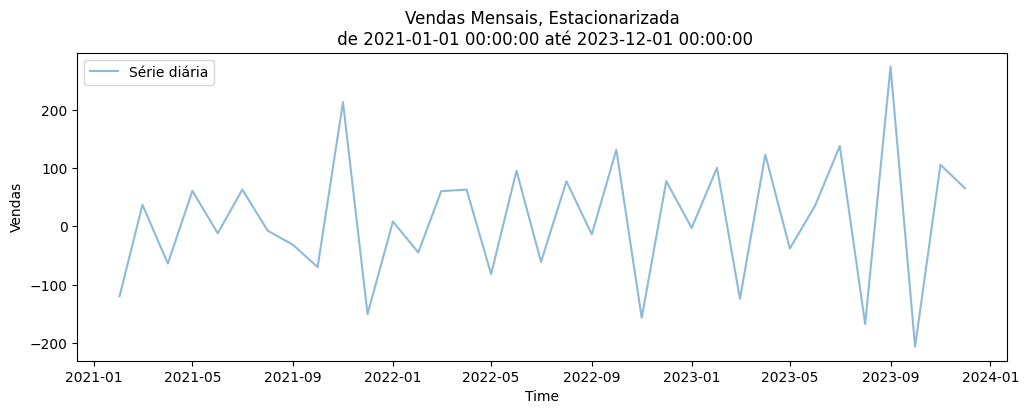

In [ ]:
plt.figure(figsize=(12, 4))

plt.plot(df.Sales.diff(1).dropna(),label='Série diária',alpha=0.5)
plt.title ('Vendas Mensais, Estacionarizada\n de ' + str(df.index.min()) + ' até ' + str(df.index.max()))
plt.xlabel('Time')
plt.ylabel ('Vendas')
plt.legend()

plt.show()

# **5. ACF e PACF, $p$ e $q$**

* **PACF (Função de Autocorrelação Parcial)**: É usada para identificar a ordem do termo autorregressivo ($p$). Se o PACF "corta" (zera) após o lag $p$, isso sugere um modelo $\text{AR}(p)$.

* **ACF (Função de Autocorrelação)**: É usada para identificar a ordem do termo de média móvel ($q$). Se o ACF "corta" após o lag $q$, isso sugere um modelo $\text{MA}(q)$.

**Notas**

* O **P**ACF e o ACF são um primeiro "chute" de valor a ser empregado para os parâmetros $p$ e $q$, muitas vezes explorando-se valores em torno desses valores iniciais ($p \pm 3$, $q \pm 3$).
* O gráfico é produzido sobre a série estacionária (a transformada, se for o caso)



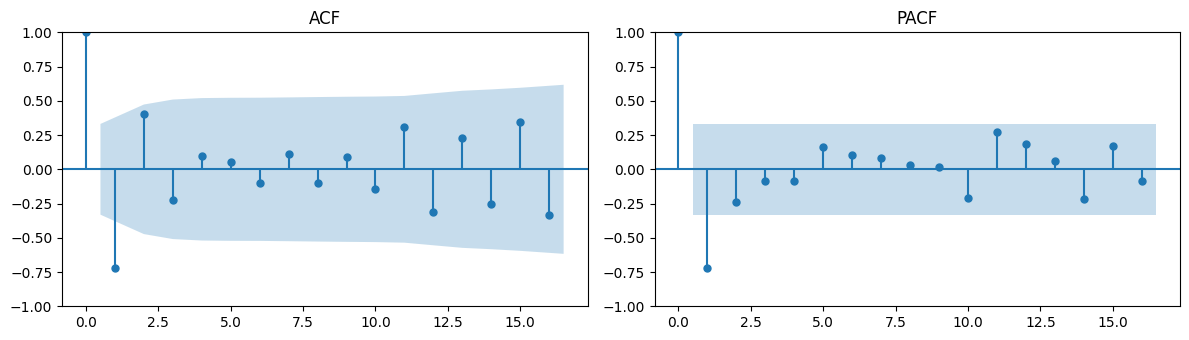

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(12,3.5))

plot_acf(df.diff(1).dropna(), ax=ax1, title='ACF' )
y=plot_pacf(df.diff(1).dropna(), ax=ax2, title='PACF')

plt.tight_layout()
plt.show()


# **6. Modelo ARIMA(p,d,q)**

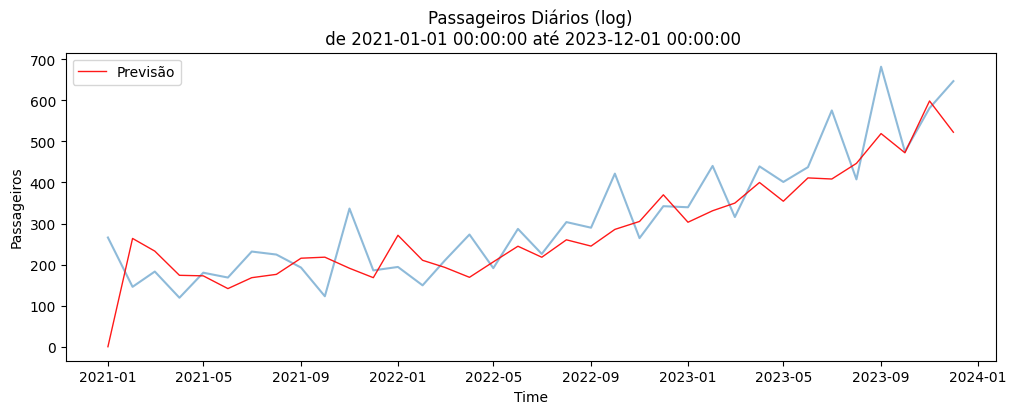

In [8]:
from statsmodels.tsa.arima.model import ARIMA

plt.figure(figsize=(12, 4))

model = ARIMA(df, order=(1, 1, 1))
model_fit = model.fit()

plt.plot(df, alpha=0.5)
plt.plot(model_fit.fittedvalues, color='r', label='Previsão', alpha=0.9, lw=1)
plt.title ('Passageiros Diários (log)\n de ' + str(df.index.min()) + ' até ' + str(df.index.max()))
plt.xlabel('Time')
plt.ylabel ('Passageiros')
plt.legend()

plt.show()

In [9]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -200.391
Date:                Fri, 05 Jun 2026   AIC                            406.782
Time:                        21:06:35   BIC                            411.448
Sample:                    01-01-2021   HQIC                           408.393
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.6003      0.201     -2.980      0.003      -0.995      -0.205
ma.L1         -0.2756      0.267     -1.033      0.302      -0.799       0.248
sigma2      5382.0426   1386.817      3.881      0.0

**Notas**

- **Coeficientes**
- **P-value dos coeficientes**, coeficientes com $p-value < 0.05$ são coeficientes significativos
- **Critério de Informação de Akaike (AIC)**, um valor menor é sempre melhor

## 6.1. Avaliando um modelo alternativo

In [11]:
# model = ARIMA(df, order=(1, 1, 1)) # Original

# for P in range(p-3,p+4):
#   for Q in range(q-3,q+4):
#     try:
p = 1
q = 0
d = 1
model_2 = ARIMA(df, order=(p,d,q))
model_2_fit = model_2.fit()

print(model_2_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   36
Model:                 ARIMA(1, 1, 0)   Log Likelihood                -201.287
Date:                Fri, 05 Jun 2026   AIC                            406.575
Time:                        21:14:31   BIC                            409.686
Sample:                    01-01-2021   HQIC                           407.649
                         - 12-01-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.7142      0.136     -5.259      0.000      -0.980      -0.448
sigma2      5683.4515   1448.557      3.924      0.000    2844.331    8522.572
Ljung-Box (L1) (Q):                   1.89   Jarque-

# **7. Análise do Modelo**

* Normalidade dos resíduos
* Resíduos não correlacionados

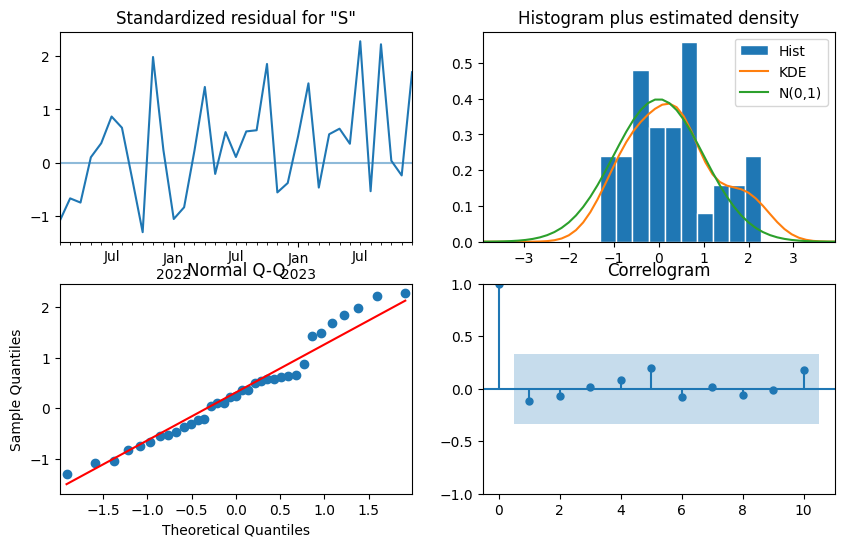

In [12]:
model_fit.plot_diagnostics(figsize=(10, 6))
plt.show()

# **8. Forecast**

**Notas**

* Por períodos\*
* Por data

2024-01-01    573.210555
2024-02-01    617.449903
2024-03-01    590.890877
Freq: MS, Name: predicted_mean, dtype: float64


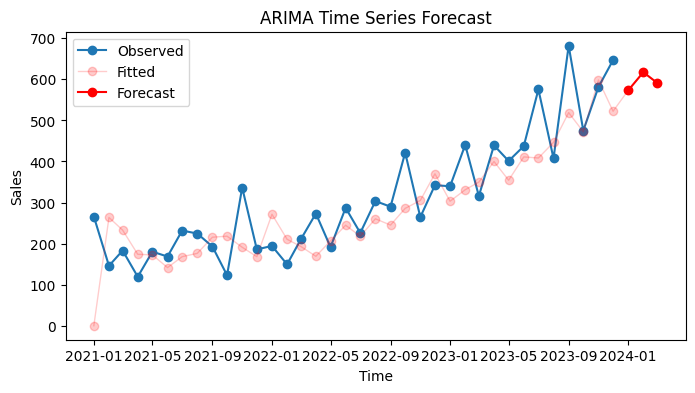

In [21]:
# Forecast 3 steps
forecast_steps = 3
predictions = model_fit.forecast(steps=forecast_steps)
print(predictions)

plt.figure(figsize=(8, 4))
plt.plot(df, label="Observed", marker="o")

plt.plot(pd.concat([model_fit.fittedvalues,predictions]), label="Fitted", marker="o", color="red", alpha=0.2, lw=1)
plt.plot(predictions, label="Forecast", marker="o", color="red")

plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.title("ARIMA Time Series Forecast")
plt.show()